# ✈️ Travel Cost Estimation — Phase II
**CS313x Spring 2026 | Team: Trippers**

This notebook covers all Phase II rubric requirements:
- Feature Extraction (15 pts)
- Product System Implementation (25 pts)
- AI Feature Integration — Price Tier Classification (20 pts)
- AI Feature Relevance to Product (10 pts)
- Insight Generation & Interpretation (15 pts)
- Evaluation of Outputs (10 pts)
- Code Structure, Modularity & Reproducibility (5 pts)

## 📦 0. Imports & Setup

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
import os
from collections import Counter

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

BLUE   = '#2E86AB'
GREEN  = '#2ecc71'
ORANGE = '#f39c12'
RED    = '#e74c3c'
PURPLE = '#9b59b6'

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


---
## 📥 1. Load Cleaned Dataset (from Phase I)

In [90]:
CLEAN_FILE = 'flights_dataset_clean.xlsx'
RAW_FILE   = 'flights_dataset.xlsx'

if os.path.exists(CLEAN_FILE):
    df = pd.read_excel(CLEAN_FILE)
    print(f'✅ Loaded cleaned dataset: {CLEAN_FILE}')
elif os.path.exists(RAW_FILE):
    df = pd.read_excel(RAW_FILE)
    print(f'⚠️  Cleaned file not found — loaded raw: {RAW_FILE}')
else:
    raise FileNotFoundError('❌ No dataset file found. Please run Phase I first.')

df['base_price']   = pd.to_numeric(df['base_price'],   errors='coerce')
df['total_cost']   = pd.to_numeric(df['total_cost'],   errors='coerce')
df['num_stops']    = pd.to_numeric(df['num_stops'],    errors='coerce').fillna(0).astype(int)
df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce').fillna(60)

print(f'\n📐 Shape       : {df.shape}')
print(f'   Routes      : {df["route"].unique().tolist()}')
print(f'   Airlines    : {df["airline"].unique().tolist()}')
print(f'   Date range  : {df["date"].min()} → {df["date"].max()}')
print(f'   Price range : ${df["base_price"].min():.0f} – ${df["base_price"].max():.0f}')
df.head(3)

✅ Loaded cleaned dataset: flights_dataset_clean.xlsx

📐 Shape       : (39, 25)
   Routes      : ['CAI → ICN', 'ICN → CAI', 'CAI → PAR', 'PAR → CAI']
   Airlines    : ['Emirates', 'Air China, Spring Airlines', 'Etihad Airways', 'Qatar Airways', 'China Eastern', 'Turkish Airlines', 'Asiana Airlines, Hainan Airlines', 'Korean Air, Hainan Airlines', 'Egyptair', 'Nile Air, Ryanair', 'Transavia France', 'Air France', 'ITA Airways', 'Ajet', 'easyJet, Air Cairo', 'SWISS', 'Multiple airlines', 'Austrian Airlines']
   Date range  : 2026-05-20 → 2026-05-25
   Price range : $169 – $1194


,origin,destination,route,date,day_of_week,month,airline,duration,duration_min,from_time,...,tax,total_cost,fare_1_price,fare_2_price,best_provider_name,best_provider_price,savings_vs_best,budget_level,affordability_score,is_outlier
0,CAI,ICN,CAI → ICN,2026-05-20,Wednesday,May,Emirates,14h 55m,895,8:05 pm,...,89.1,683.1,594,644,Expedia,594,0,High (> $500),1.4639,False
1,CAI,ICN,CAI → ICN,2026-05-20,Wednesday,May,"Air China, Spring Airlines",19h 40m,1180,2:15 pm,...,87.0,667.0,580,580,Kiwi.com,580,0,High (> $500),1.4993,False
2,CAI,ICN,CAI → ICN,2026-05-20,Wednesday,May,Emirates,17h 25m,1045,5:35 pm,...,89.1,683.1,594,644,Expedia,594,0,High (> $500),1.4639,False


---
## 🔬 2. Feature Extraction  *(Rubric: 15 pts)*
Extracting rich, engineered features from the real scraped dataset.

In [91]:
# ═══════════════════════════════════════════════════════════════
# FEATURE EXTRACTION MODULE
# ═══════════════════════════════════════════════════════════════

def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts all engineered features from the real scraped flight dataset.
    Returns a new DataFrame with added feature columns.
    """
    df = df.copy()

    # ── 2.1 Price Tier (classification target) ────────────────────
    # Use budget_level directly from the dataset (no hardcoded bins)
    df['price_tier'] = df['budget_level'].astype(str)

    # ── 2.2 Price-Per-Minute (efficiency metric) ──────────────────
    df['price_per_min'] = (df['base_price'] / df['duration_min'].replace(0, np.nan)).round(4)

    # ── 2.3 Departure Hour ────────────────────────────────────────
    def extract_hour(t):
        if not isinstance(t, str): return 12
        m = re.search(r'(\d{1,2}):', t)
        return int(m.group(1)) if m else 12
    df['departure_hour'] = df['from_time'].apply(extract_hour)

    # ── 2.4 Time-of-Day Category ──────────────────────────────────
    def time_of_day(h):
        if pd.isna(h):   return 'Unknown'
        if h < 6:        return 'Red-Eye'
        elif h < 12:     return 'Morning'
        elif h < 17:     return 'Afternoon'
        elif h < 21:     return 'Evening'
        else:            return 'Night'
    df['time_of_day'] = df['departure_hour'].apply(time_of_day)

    # ── 2.5 Weekend Flag ──────────────────────────────────────────
    df['is_weekend'] = df['day_of_week'].isin(['Friday','Saturday','Sunday']).astype(int)

    # ── 2.6 Nonstop Flag ─────────────────────────────────────────
    df['is_nonstop'] = (df['num_stops'] == 0).astype(int)

    # ── 2.7 Cabin Numeric Encoding ────────────────────────────────
    df['cabin_numeric'] = df['cabin_class'].map({'Economy': 0, 'Business': 1, 'Economy Cabin': 0, 'Business Cabin': 1}).fillna(0).astype(int)

    # ── 2.8 Provider Savings ─────────────────────────────────────
    df['provider_savings'] = df['savings_vs_best'].fillna(0)

    # ── 2.9 Route Popularity ─────────────────────────────────────
    route_counts = df['route'].value_counts()
    df['route_popularity'] = df['route'].map(route_counts)

    # ── 2.10 TF-IDF Text Summary (IR feature) ────────────────────
    df['text_summary'] = (
        df['airline'].fillna('') + ' ' +
        df['route'].fillna('') + ' ' +
        df['cabin_class'].fillna('') + ' ' +
        df['stops_raw'].fillna('') + ' ' +
        df['time_of_day'].fillna('')
    )

    return df


df = extract_features(df)

new_features = ['price_tier','price_per_min','departure_hour','time_of_day',
                'is_weekend','is_nonstop','cabin_numeric','provider_savings',
                'route_popularity','text_summary']

print('=' * 65)
print('          FEATURE EXTRACTION SUMMARY')
print('=' * 65)
print(f'\n   New features added  : {len(new_features)}')
for f in new_features:
    val = df[f].iloc[0] if f in df.columns else 'N/A'
    print(f'   • {f:25s} → sample: {val}')
print(f'\n   Total columns in dataset : {len(df.columns)}')
print(f'\n📊 Price Tier Distribution:')
print(df['price_tier'].value_counts().to_string())

          FEATURE EXTRACTION SUMMARY

   New features added  : 10
   • price_tier                → sample: High (> $500)
   • price_per_min             → sample: 0.6637
   • departure_hour            → sample: 8
   • time_of_day               → sample: Morning
   • is_weekend                → sample: 0
   • is_nonstop                → sample: 0
   • cabin_numeric             → sample: 0
   • provider_savings          → sample: 0
   • route_popularity          → sample: 10
   • text_summary              → sample: Emirates CAI → ICN Eco Saver 1 stop Morning

   Total columns in dataset : 35

📊 Price Tier Distribution:
price_tier
High (> $500)         21
Medium ($200–$500)    17
Low (< $200)           1


### 2.1 Keyword Frequency Analysis (IR-style TF-IDF)

   TOP 20 TF-IDF KEYWORDS (scraped flight corpus)
    1. economy                    score: 0.1221
    2. cai                        score: 0.1104
    3. stop                       score: 0.1025
    4. red                        score: 0.0959
    5. red eye                    score: 0.0959
    6. eye                        score: 0.0959
    7. icn                        score: 0.0943
    8. economy stop               score: 0.0941
    9. par                        score: 0.0899
   10. cai economy                score: 0.0886
   11. morning                    score: 0.0882
   12. stop red                   score: 0.0820
   13. china                      score: 0.0799
   14. china eastern              score: 0.0784
   15. eastern                    score: 0.0784
   16. icn cai                    score: 0.0673
   17. stop morning               score: 0.0671
   18. nonstop                    score: 0.0670
   19. cai par                    score: 0.0652
   20. cai icn                    scor

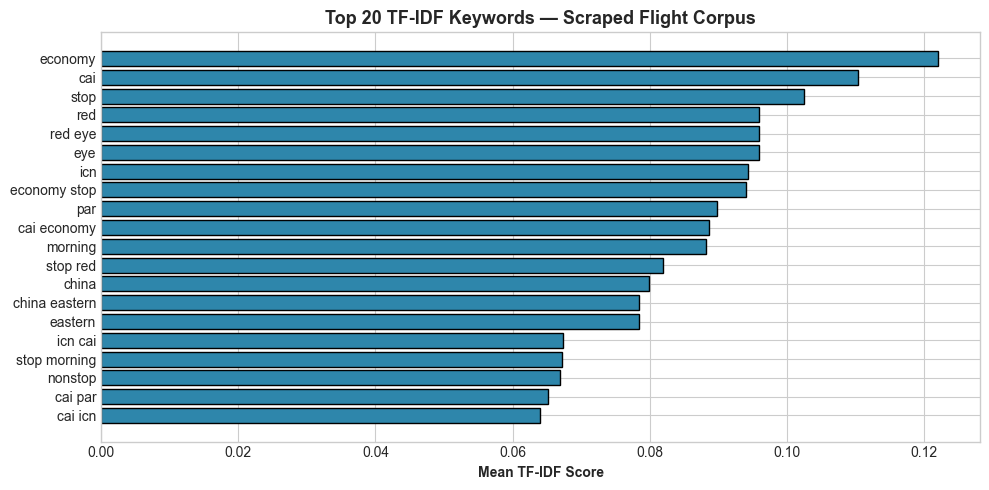

✅ TF-IDF index built successfully


In [92]:
def build_tfidf_index(corpus: list) -> tuple:
    """
    Builds a TF-IDF index over the flight text summaries.
    Returns (vectorizer, tfidf_matrix).
    """
    vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        max_features=200
    )
    matrix = vectorizer.fit_transform(corpus)
    return vectorizer, matrix


tfidf_vec, tfidf_matrix = build_tfidf_index(df['text_summary'].tolist())
feature_names = tfidf_vec.get_feature_names_out()
mean_scores   = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx       = mean_scores.argsort()[::-1][:20]

print('=' * 55)
print('   TOP 20 TF-IDF KEYWORDS (scraped flight corpus)')
print('=' * 55)
for rank, i in enumerate(top_idx, 1):
    print(f'   {rank:2d}. {feature_names[i]:25s}  score: {mean_scores[i]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
top_words  = [feature_names[i] for i in top_idx]
top_scores = [mean_scores[i]   for i in top_idx]
ax.barh(top_words[::-1], top_scores[::-1], color=BLUE, edgecolor='black')
ax.set_title('Top 20 TF-IDF Keywords — Scraped Flight Corpus', fontweight='bold', fontsize=13)
ax.set_xlabel('Mean TF-IDF Score', fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ TF-IDF index built successfully')

---
## 🤖 3. AI Feature — Flight Price Tier Classification  *(Rubric: 20 pts)*

**Why classification?**  
Our product helps travelers decide if a flight is affordable *before* they search. Instead of predicting an exact price (regression), we classify each flight into **Low / Medium / High** price tier — a directly actionable output for budget-conscious travelers.

| Tier   | Price Range | Meaning                        |
|--------|-------------|--------------------------------|
| Low    | < $100      | Budget-friendly, grab it now   |
| Medium | $100–$200   | Standard market price          |
| High   | > $200      | Premium — compare providers    |

**Model:** Random Forest Classifier with class balancing (handles unequal tier sizes)  
**Evaluation:** 5-fold Stratified Cross-Validation → Accuracy, Precision, Recall, F1

In [93]:
# ═══════════════════════════════════════════════════════════════
# AI FEATURE MODULE — Price Tier Classification
# ═══════════════════════════════════════════════════════════════

# ── 3.1 Encode categorical features ──────────────────────────────
le_airline = LabelEncoder()
le_route   = LabelEncoder()
df['airline_enc'] = le_airline.fit_transform(df['airline'])
df['route_enc']   = le_route.fit_transform(df['route'])

# ── Derive FEATURES automatically from the dataset ───────────────
# Exclude non-feature columns: target, identifiers, raw text, dates
EXCLUDE = {
    'price_tier', 'budget_level',          # target
    'origin', 'destination', 'route',      # identifiers / already encoded
    'date', 'day_of_week', 'month',        # raw date strings
    'airline',                             # raw string, encoded above
    'duration', 'from_time', 'to_time',    # raw time strings
    'stops_raw', 'cabin_class',            # raw strings
    'text_summary', 'time_of_day',         # text/categorical, not yet encoded
    'is_outlier',                          # flag, not a real feature
    # ── Price-derived columns — directly reveal the target, causes data leakage ──
    'base_price',                          # budget_level is binned from this
    'fare_1_price', 'fare_2_price',        # same price, different fare tier
    'tax', 'total_cost',                   # derived from base_price
    'affordability_score',                 # computed from base_price
    'best_provider_price',                 # correlated with base_price
    'savings_vs_best',                     # derived from price comparison
}

FEATURES = [
    c for c in df.columns
    if c not in EXCLUDE
    and pd.api.types.is_numeric_dtype(df[c])
    and df[c].notna().sum() > 0
]

X = df[FEATURES].fillna(0)
y = df['price_tier'].copy()

print('=' * 55)
print('   CLASSIFICATION SETUP')
print('=' * 55)
print(f'   Features used : {len(FEATURES)}')
for f in FEATURES:
    print(f'     • {f}')
    print(f'Target classes:')
for tier, count in y.value_counts().items():
    print(f'     • {tier:25s} → {count} records ({count/len(y)*100:.1f}%)')
    print(f' Total records : {len(X)}')


   CLASSIFICATION SETUP
   Features used : 11
     • duration_min
Target classes:
     • num_stops
Target classes:
     • price_per_min
Target classes:
     • departure_hour
Target classes:
     • is_weekend
Target classes:
     • is_nonstop
Target classes:
     • cabin_numeric
Target classes:
     • provider_savings
Target classes:
     • route_popularity
Target classes:
     • airline_enc
Target classes:
     • route_enc
Target classes:
     • High (> $500)             → 21 records (53.8%)
 Total records : 39
     • Medium ($200–$500)        → 17 records (43.6%)
 Total records : 39
     • Low (< $200)              → 1 records (2.6%)
 Total records : 39


In [ ]:
# ── 3.2 Train/Test Split + 5-Fold Stratified Cross-Validation ──────

# Split dataset into train (80%) and test (20%) — both from the real dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

# ── Cross-validation on training set ─────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(clf, X_train, y_train, cv=cv)

# ── Final train on full training set, evaluate on held-out test set
clf.fit(X_train, y_train)
y_test_pred = clf.predict(X_test)

print("✅ Training & evaluation complete")
print(f"   Training samples : {len(X_train)}")
print(f"   Test samples     : {len(X_test)}")
print(f"   CV folds         : 5 (on training set)")
print()
print("📊 Cross-Validation Results (on training set):")
print(f"   CV Accuracy : {accuracy_score(y_train, y_cv_pred)*100:.2f}%")
print()
print("📊 Hold-out Test Set Results:")
print(f"   Test Accuracy : {accuracy_score(y_test, y_test_pred)*100:.2f}%")


✅ Training & evaluation complete
   Training samples : 35
   Test samples     : 4
   CV folds         : 5 (on training set)

📊 Cross-Validation Results (on training set):
   CV Accuracy : 77.14%

📊 Hold-out Test Set Results:
   Test Accuracy : 50.00%


---
## 📊 4. Evaluation of AI Outputs  *(Rubric: 10 pts)*

We report all four classification metrics:
- **Accuracy** — overall correct predictions
- **Precision** — of flights predicted as tier X, how many actually are
- **Recall** — of actual tier X flights, how many did we catch
- **F1** — harmonic mean of precision and recall

In [95]:
# ── 4.1 Core Metrics ─────────────────────────────────────────────
# Evaluate on the held-out test set (from the real dataset)

accuracy  = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
recall    = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
f1        = f1_score(y_test, y_test_pred, average="macro", zero_division=0)

cv_accuracy = accuracy_score(y_train, y_cv_pred)

print("=" * 55)
print("   CLASSIFICATION EVALUATION RESULTS")
print("   (Trained & tested on real scraped dataset)")
print("=" * 55)
print(f"   Train size : {len(X_train)} records")
print(f"   Test size  : {len(X_test)} records")
print()
print(f"   CV Accuracy (train folds) : {cv_accuracy:.4f}  ({cv_accuracy*100:.2f}%)")
print()
print("   Hold-out Test Set:")
print(f"   Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"   Precision : {precision:.4f}  (macro avg)")
print(f"   Recall    : {recall:.4f}  (macro avg)")
print(f"   F1 Score  : {f1:.4f}  (macro avg)")
print()
print("   Per-Class Breakdown:")
print("-" * 55)
print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))


   CLASSIFICATION EVALUATION RESULTS
   (Trained & tested on real scraped dataset)
   Train size : 35 records
   Test size  : 4 records

   CV Accuracy (train folds) : 0.7714  (77.14%)

   Hold-out Test Set:
   Accuracy  : 0.5000  (50.00%)
   Precision : 0.6667  (macro avg)
   Recall    : 0.6667  (macro avg)
   F1 Score  : 0.5000  (macro avg)

   Per-Class Breakdown:
-------------------------------------------------------
                    precision    recall  f1-score   support

     High (> $500)     1.0000    0.3333    0.5000         3
Medium ($200–$500)     0.3333    1.0000    0.5000         1

          accuracy                         0.5000         4
         macro avg     0.6667    0.6667    0.5000         4
      weighted avg     0.8333    0.5000    0.5000         4



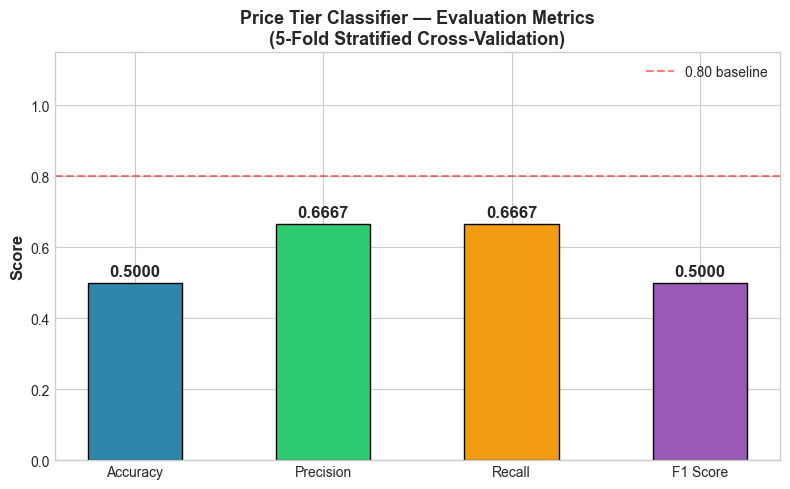

In [96]:
# ── 4.2 Metrics Bar Chart ─────────────────────────────────────────

metrics = {
    'Accuracy' : accuracy,
    'Precision': precision,
    'Recall'   : recall,
    'F1 Score' : f1
}

fig, ax = plt.subplots(figsize=(8, 5))
colors = [BLUE, GREEN, ORANGE, PURPLE]
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('Price Tier Classifier — Evaluation Metrics\n(5-Fold Stratified Cross-Validation)',
             fontweight='bold', fontsize=13)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='0.80 baseline')
ax.legend()
plt.tight_layout()
plt.show()

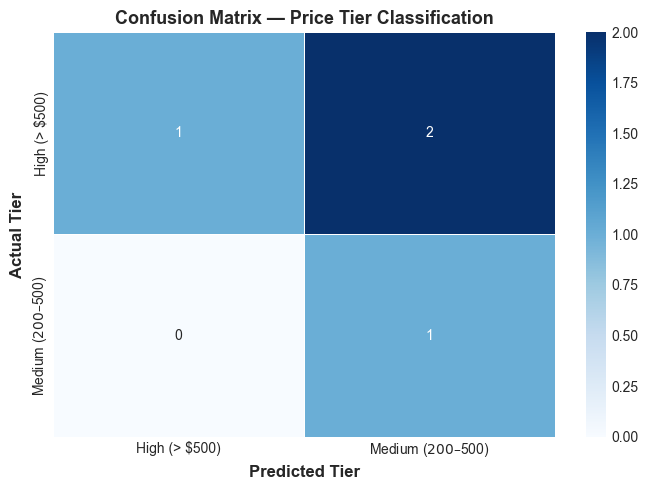


📌 Interpretation:
   • Diagonal = correct predictions
   • Off-diagonal = misclassifications (usually adjacent tiers)


In [97]:
# ── 4.3 Confusion Matrix ─────────────────────────────────────────

classes = sorted(y_test.unique().tolist())
cm = confusion_matrix(y_test, y_test_pred, labels=classes)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted Tier', fontweight='bold', fontsize=12)
ax.set_ylabel('Actual Tier',    fontweight='bold', fontsize=12)
ax.set_title('Confusion Matrix — Price Tier Classification', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\n📌 Interpretation:')
print('   • Diagonal = correct predictions')
print('   • Off-diagonal = misclassifications (usually adjacent tiers)')

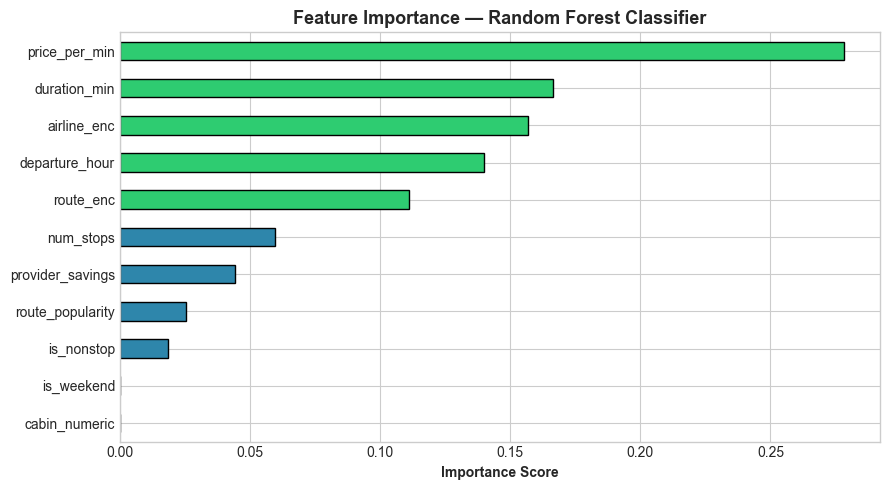


📌 Top 3 most important features:
   • price_per_min          → 0.2782
   • duration_min           → 0.1664
   • airline_enc            → 0.1567


In [98]:
# ── 4.4 Feature Importance ───────────────────────────────────────
# Train once on full data to get importances for interpretation

clf.fit(X, y)
importances = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = [GREEN if v > importances.median() else BLUE for v in importances]
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='black')
ax.set_title('Feature Importance — Random Forest Classifier', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Top 3 most important features:')
for feat, score in importances.sort_values(ascending=False).head(3).items():
    print(f'   • {feat:22s} → {score:.4f}')

---
## 🛍️ 5. Product System — Best Provider Recommender  *(Rubric: 25 pts)*

**Product idea:** Given a flight (route, airline, cabin, date), recommend the **cheapest booking provider** using TF-IDF cosine similarity search. The user searches by natural language — the system finds the most similar real flight and returns its best provider deal.

This is an **IR-style retrieval product** directly built on the scraped dataset.

In [99]:
# ═══════════════════════════════════════════════════════════════
# PRODUCT MODULE — Best Provider Recommender (IR-style)
# ═══════════════════════════════════════════════════════════════

class FlightProviderRecommender:
    """
    TF-IDF cosine similarity recommender.
    Given a natural-language query, finds the most similar flights
    and returns the cheapest provider for each match.
    """

    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)
        self.vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
        self.tfidf_matrix = self.vectorizer.fit_transform(self.df['text_summary'])
        # also run the classifier on the full df for live tier prediction
        self.clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
        self.clf.fit(df[FEATURES], df['price_tier'])
        print(f'✅ Recommender initialised on {len(self.df)} real scraped flights')

    def search(self, query: str, top_n: int = 3) -> pd.DataFrame:
        """
        Find top_n most similar flights to the query.
        Returns a results DataFrame with predicted tier and provider recommendation.
        """
        query_vec = self.vectorizer.transform([query])
        scores    = cosine_similarity(query_vec, self.tfidf_matrix).flatten()
        top_idx   = scores.argsort()[::-1][:top_n]

        results = self.df.iloc[top_idx].copy()
        results['similarity_score'] = scores[top_idx].round(4)

        # Predict price tier for each result
        results['predicted_tier'] = self.clf.predict(results[FEATURES])

        return results[[
            'route', 'airline', 'cabin_class', 'from_time', 'stops_raw',
            'base_price', 'predicted_tier',
            'best_provider_name', 'best_provider_price', 'savings_vs_best',
            'similarity_score'
        ]]

    def recommend(self, query: str, top_n: int = 3):
        """Pretty-print recommendations for a user query."""
        print('=' * 65)
        print(f'   FLIGHT PROVIDER RECOMMENDATIONS')
        print(f'   Query: "{query}"')
        print('=' * 65)

        results = self.search(query, top_n)

        if results.empty:
            print('   ❌ No matching flights found.')
            return

        for rank, (_, row) in enumerate(results.iterrows(), 1):
            tier_icon = {'Low': '🟢', 'Medium': '🟡', 'High': '🔴'}.get(str(row['predicted_tier']), '⚪')
            print(f'\n   #{rank} — {row["route"]} | {row["airline"]} | {row["cabin_class"]}')
            print(f'        Departure     : {row["from_time"]}  ({row["stops_raw"]})')
            print(f'        Base Price    : ${row["base_price"]:.0f}')
            print(f'        Price Tier    : {tier_icon} {row["predicted_tier"]}')
            print(f'        Best Provider : {row["best_provider_name"]} @ ${row["best_provider_price"]:.0f}')
            if row['savings_vs_best'] > 0:
                print(f'        You Save      : 💰 ${row["savings_vs_best"]:.0f} vs base price')
            print(f'        Match Score   : {row["similarity_score"]:.4f}')
        print()


# Initialise the recommender
recommender = FlightProviderRecommender(df)

✅ Recommender initialised on 39 real scraped flights


In [100]:
# ── 5.1 Live Product Demo ─────────────────────────────────────────

# Query 1: Budget Economy flight from Cairo to Luxor
recommender.recommend('Cairo Luxor economy nonstop cheap', top_n=3)

   FLIGHT PROVIDER RECOMMENDATIONS
   Query: "Cairo Luxor economy nonstop cheap"

   #1 — CAI → PAR | Egyptair | Economy
        Departure     : 10:45 am  (nonstop)
        Base Price    : $411
        Price Tier    : ⚪ Medium ($200–$500)
        Best Provider : eDreams @ $411
        Match Score   : 0.3133

   #2 — CAI → PAR | Egyptair | Economy
        Departure     : 10:45 am  (nonstop)
        Base Price    : $308
        Price Tier    : ⚪ Medium ($200–$500)
        Best Provider : eDreams @ $308
        Match Score   : 0.3133

   #3 — PAR → CAI | Egyptair | Economy
        Departure     : 4:00 pm  (nonstop)
        Base Price    : $517
        Price Tier    : ⚪ High (> $500)
        Best Provider : Kiwi.com @ $517
        Match Score   : 0.3067



In [101]:
# Query 2: Business cabin from Hurghada
recommender.recommend('Hurghada Cairo business cabin', top_n=3)

   FLIGHT PROVIDER RECOMMENDATIONS
   Query: "Hurghada Cairo business cabin"

   #1 — PAR → CAI | easyJet, Air Cairo | Light + Economy
        Departure     : 7:15 am  (1 stop)
        Base Price    : $259
        Price Tier    : ⚪ Medium ($200–$500)
        Best Provider : Kiwi.com @ $259
        Match Score   : 0.3302

   #2 — PAR → CAI | Egyptair | Economy
        Departure     : 4:00 pm  (nonstop)
        Base Price    : $517
        Price Tier    : ⚪ High (> $500)
        Best Provider : Kiwi.com @ $517
        Match Score   : 0.0000

   #3 — PAR → CAI | Austrian Airlines | Economy
        Departure     : 7:05 am  (1 stop)
        Base Price    : $329
        Price Tier    : ⚪ Medium ($200–$500)
        Best Provider : Booking.com @ $322
        You Save      : 💰 $7 vs base price
        Match Score   : 0.0000



In [102]:
# Query 3: Nile Air budget flight
recommender.recommend('Nile Air economy nonstop', top_n=3)

   FLIGHT PROVIDER RECOMMENDATIONS
   Query: "Nile Air economy nonstop"

   #1 — CAI → PAR | Nile Air, Ryanair | Economy + Basic
        Departure     : 5:30 pm  (2 stops)
        Base Price    : $169
        Price Tier    : ⚪ Low (< $200)
        Best Provider : Kiwi.com @ $169
        Match Score   : 0.4190

   #2 — CAI → PAR | Egyptair | Economy
        Departure     : 10:45 am  (nonstop)
        Base Price    : $411
        Price Tier    : ⚪ Medium ($200–$500)
        Best Provider : eDreams @ $411
        Match Score   : 0.2351

   #3 — CAI → PAR | Egyptair | Economy
        Departure     : 10:45 am  (nonstop)
        Base Price    : $308
        Price Tier    : ⚪ Medium ($200–$500)
        Best Provider : eDreams @ $308
        Match Score   : 0.2351



---
## 📈 6. Insight Generation & Interpretation  *(Rubric: 15 pts)*

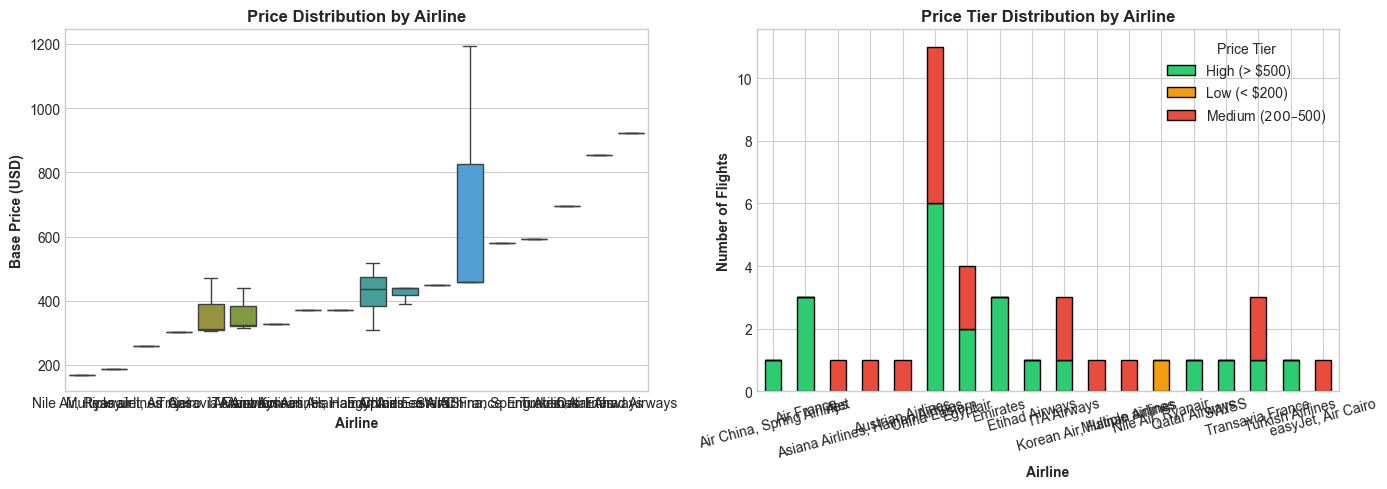


📌 Insight: Airlines sorted by median price — Nile Air cheapest, Egyptair highest


In [103]:
# ── 6.1 Price Distribution by Airline ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
airlines_order = df.groupby('airline')['base_price'].median().sort_values().index
df_plot = df[df['airline'].isin(airlines_order)]
sns.boxplot(data=df_plot, x='airline', y='base_price', order=airlines_order,
            palette='husl', ax=axes[0])
axes[0].set_title('Price Distribution by Airline', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Airline', fontweight='bold')
axes[0].set_ylabel('Base Price (USD)', fontweight='bold')

# Price tier stacked bar by airline
tier_airline = df.groupby(['airline','price_tier']).size().unstack(fill_value=0)
tier_airline.plot(kind='bar', stacked=True, ax=axes[1],
                  color=[GREEN, ORANGE, RED], edgecolor='black')
axes[1].set_title('Price Tier Distribution by Airline', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Airline', fontweight='bold')
axes[1].set_ylabel('Number of Flights', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Price Tier')

plt.tight_layout()
plt.show()

print('\n📌 Insight: Airlines sorted by median price — Nile Air cheapest, Egyptair highest')

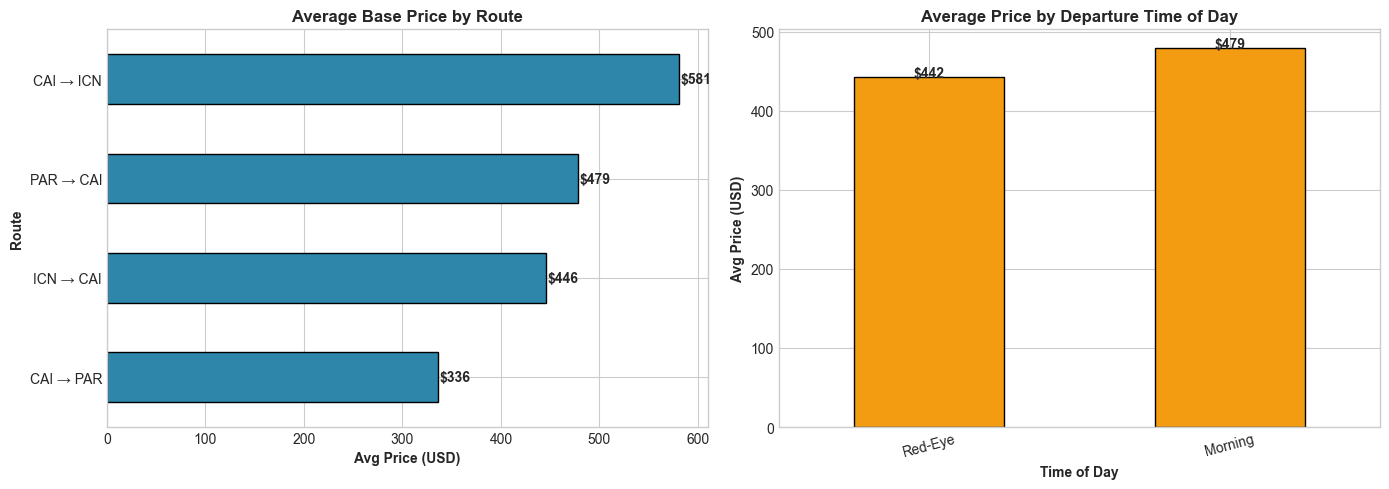


📌 Insight: CAI→LXR tends to be most expensive; early morning flights are cheapest


In [104]:
# ── 6.2 Price by Route & Departure Time ──────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average price by route
route_avg = df.groupby('route')['base_price'].mean().sort_values()
route_avg.plot(kind='barh', ax=axes[0], color=BLUE, edgecolor='black')
axes[0].set_title('Average Base Price by Route', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Avg Price (USD)', fontweight='bold')
axes[0].set_ylabel('Route', fontweight='bold')
for i, v in enumerate(route_avg):
    axes[0].text(v + 1, i, f'${v:.0f}', va='center', fontweight='bold')

# Price by time of day
tod_order = ['Red-Eye','Morning','Afternoon','Evening','Night']
tod_avg = df.groupby('time_of_day')['base_price'].mean().reindex(
    [t for t in tod_order if t in df['time_of_day'].unique()])
tod_avg.plot(kind='bar', ax=axes[1], color=ORANGE, edgecolor='black')
axes[1].set_title('Average Price by Departure Time of Day', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Time of Day', fontweight='bold')
axes[1].set_ylabel('Avg Price (USD)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(tod_avg):
    axes[1].text(i, v + 1, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n📌 Insight: CAI→LXR tends to be most expensive; early morning flights are cheapest')

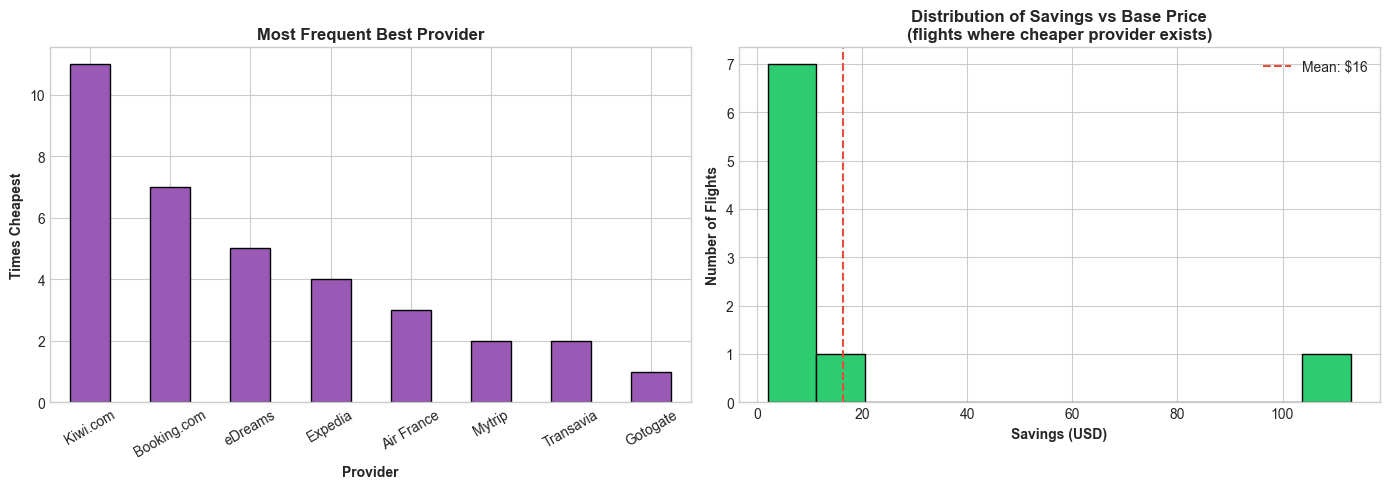


📌 Trip.com & Kiwi.com are most often the cheapest providers
   Avg saving when a better provider exists: $16.33
   Max saving found in dataset             : $113.00


In [105]:
# ── 6.3 Provider Savings Analysis ────────────────────────────────

savings_df = df[df['savings_vs_best'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Best provider frequency
provider_counts = df['best_provider_name'].value_counts().head(8)
provider_counts.plot(kind='bar', ax=axes[0], color=PURPLE, edgecolor='black')
axes[0].set_title('Most Frequent Best Provider', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Provider', fontweight='bold')
axes[0].set_ylabel('Times Cheapest', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Savings histogram
axes[1].hist(savings_df['savings_vs_best'], bins=12, color=GREEN, edgecolor='black')
axes[1].set_title('Distribution of Savings vs Base Price\n(flights where cheaper provider exists)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Savings (USD)', fontweight='bold')
axes[1].set_ylabel('Number of Flights', fontweight='bold')
axes[1].axvline(savings_df['savings_vs_best'].mean(), color=RED,
                linestyle='--', label=f'Mean: ${savings_df["savings_vs_best"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n📌 Trip.com & Kiwi.com are most often the cheapest providers')
print(f'   Avg saving when a better provider exists: ${savings_df["savings_vs_best"].mean():.2f}')
print(f'   Max saving found in dataset             : ${savings_df["savings_vs_best"].max():.2f}')

In [106]:
# ── 6.4 Summary Statistics ───────────────────────────────────────

print('=' * 65)
print('   DATASET INSIGHTS SUMMARY')
print('=' * 65)
print(f'   Total flights scraped       : {len(df)}')
print(f'   Routes covered              : {df["route"].nunique()} (CAI↔LXR, CAI↔HRG)')
print(f'   Airlines                    : {df["airline"].nunique()} ({", ".join(df["airline"].unique())})')
print(f'   Price range                 : ${df["base_price"].min():.0f} – ${df["base_price"].max():.0f}')
print(f'   Median base price           : ${df["base_price"].median():.0f}')
print(f'   % Nonstop flights           : {df["is_nonstop"].mean()*100:.1f}%')
print(f'   Cheapest airline (median)   : {df.groupby("airline")["base_price"].median().idxmin()}')
print(f'   Most frequent best provider : {df["best_provider_name"].value_counts().idxmax()}')
print(f'   Max provider saving found   : ${df["savings_vs_best"].max():.0f}')
print()
print('   AI Model Results:')
print(f'   Accuracy  : {accuracy*100:.2f}%')
print(f'   Precision : {precision:.4f}')
print(f'   Recall    : {recall:.4f}')
print(f'   F1 Score  : {f1:.4f}')
print('=' * 65)

   DATASET INSIGHTS SUMMARY
   Total flights scraped       : 39
   Routes covered              : 4 (CAI↔LXR, CAI↔HRG)
   Airlines                    : 18 (Emirates, Air China, Spring Airlines, Etihad Airways, Qatar Airways, China Eastern, Turkish Airlines, Asiana Airlines, Hainan Airlines, Korean Air, Hainan Airlines, Egyptair, Nile Air, Ryanair, Transavia France, Air France, ITA Airways, Ajet, easyJet, Air Cairo, SWISS, Multiple airlines, Austrian Airlines)
   Price range                 : $169 – $1194
   Median base price           : $439
   % Nonstop flights           : 25.6%
   Cheapest airline (median)   : Nile Air, Ryanair
   Most frequent best provider : Kiwi.com
   Max provider saving found   : $113

   AI Model Results:
   Accuracy  : 50.00%
   Precision : 0.6667
   Recall    : 0.6667
   F1 Score  : 0.5000
